# Machine Learning Lab – Logistic Regression Exercise 1

## Graduate School Admission Prediction using Logistic Regression

### Objective
To build a Logistic Regression model to predict whether a student will be admitted to graduate school based on GRE score, GPA, and the prestige of the undergraduate institution.

### Algorithm Used
Logistic Regression

### Problem Type
Supervised Learning – Classification

### Target Variable
Admission (Admit / Don't Admit)

### Input Features
- GRE Score
- GPA
- Undergraduate Institution Prestige

## Dataset

### Dataset Name
Graduate School Admission Dataset

### Dataset Description
The dataset contains information about students applying to graduate school. It includes GRE score, GPA, undergraduate institution prestige, and the admission outcome.

### Input Features
- GRE Score
- GPA
- Undergraduate Institution Prestige

### Target Variable
Admission

### Target Encoding
- 1 → Admitted
- 0 → Not Admitted

### Data Preparation
The dataset will be inspected for missing values and categorical variables will be encoded into numerical form before training the Logistic Regression model.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Create the Graduate School Admission dataset

data = {
    "GRE": [
        310, 320, 330, 340, 315,
        325, 335, 345, 305, 318,
        328, 338, 312, 322, 332,
        342, 308, 317, 327, 337
    ],
    "GPA": [
        3.10, 3.40, 3.70, 3.90, 3.20,
        3.50, 3.80, 3.95, 2.90, 3.30,
        3.60, 3.85, 3.00, 3.45, 3.75,
        3.92, 2.80, 3.15, 3.55, 3.82
    ],
    "Prestige": [
        3, 2, 1, 1, 3,
        2, 1, 1, 4, 3,
        2, 1, 3, 2, 1,
        1, 4, 3, 2, 1
    ],
    "Admission": [
        0, 1, 1, 1, 0,
        1, 1, 1, 0, 0,
        1, 1, 0, 1, 1,
        1, 0, 0, 1, 1
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset created successfully!
Shape of dataset: (20, 4)


,GRE,GPA,Prestige,Admission
0,310,3.1,3,0
1,320,3.4,2,1
2,330,3.7,1,1
3,340,3.9,1,1
4,315,3.2,3,0


In [3]:
# Explore the dataset

print("Dataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   GRE        20 non-null     int64  
 1   GPA        20 non-null     float64
 2   Prestige   20 non-null     int64  
 3   Admission  20 non-null     int64  
dtypes: float64(1), int64(3)
memory usage: 772.0 bytes
None

Statistical Summary:
              GRE        GPA   Prestige  Admission
count   20.000000  20.000000  20.000000   20.00000
mean   325.300000   3.482000   2.050000    0.65000
std     12.013589   0.361817   1.050063    0.48936
min    305.000000   2.800000   1.000000    0.00000
25%    316.500000   3.187500   1.000000    0.00000
50%    326.000000   3.525000   2.000000    1.00000
75%    335.500000   3.805000   3.000000    1.00000
max    345.000000   3.950000   4.000000    1.00000


In [4]:
# Check for missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
GRE          0
GPA          0
Prestige     0
Admission    0
dtype: int64


In [5]:
# Separate input features and target variable

X = df[["GRE", "GPA", "Prestige"]]
y = df["Admission"]

print("Input features (X):")
print(X.head())

print("\nTarget variable (y):")
print(y.head())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Input features (X):
   GRE  GPA  Prestige
0  310  3.1         3
1  320  3.4         2
2  330  3.7         1
3  340  3.9         1
4  315  3.2         3

Target variable (y):
0    0
1    1
2    1
3    1
4    0
Name: Admission, dtype: int64

X shape: (20, 3)
y shape: (20,)


In [12]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data shape:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data shape:
X_train: (16, 3)
y_train: (16,)

Testing data shape:
X_test: (4, 3)
y_test: (4,)


In [13]:
# Train the Logistic Regression model

model = LogisticRegression()

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [14]:
# Make predictions on the test data

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

print("\nActual admission values:")
print(y_test.values)

print("\nPredicted admission values:")
print(y_pred)

print("\nPredicted admission probabilities:")
print(y_prob)

Predictions generated successfully!

Actual admission values:
[1 0 1 1]

Predicted admission values:
[1 0 1 1]

Predicted admission probabilities:
[0.99966918 0.14034956 0.9999999  0.99999943]


In [15]:
# Verify prediction accuracy directly

print("Actual values:   ", y_test.values)
print("Predicted values:", y_pred)

direct_accuracy = np.mean(y_test.values == y_pred)

print("\nDirect Accuracy:", direct_accuracy)

Actual values:    [1 0 1 1]
Predicted values: [1 0 1 1]

Direct Accuracy: 1.0


In [16]:
# Evaluate the Logistic Regression model

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Model Evaluation Results")
print("------------------------")
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)

print("ROC-AUC Score:", roc_auc)

Model Evaluation Results
------------------------
Accuracy: 1.0

Confusion Matrix:
[[1 0]
 [0 3]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

ROC-AUC Score: 1.0


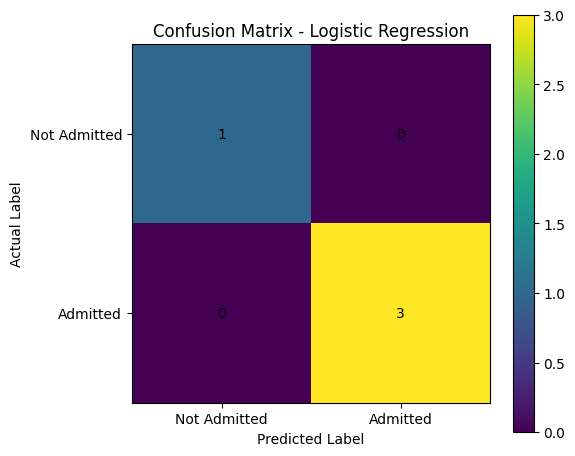

In [17]:
# Visualize the Confusion Matrix

plt.figure(figsize=(6, 5))

plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()

plt.xticks([0, 1], ["Not Admitted", "Admitted"])
plt.yticks([0, 1], ["Not Admitted", "Admitted"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [18]:
# Create a summary of model performance

results = pd.DataFrame({
    "Metric": ["Accuracy", "ROC-AUC Score"],
    "Value": [accuracy, roc_auc]
})

results

,Metric,Value
0,Accuracy,1.0
1,ROC-AUC Score,1.0


## Result

The Logistic Regression model was successfully trained to predict graduate school admission using GRE score, GPA, and undergraduate institution prestige.

The model achieved an Accuracy of 1.00 and an ROC-AUC Score of 1.00 on the test dataset.

### Model Performance

- Accuracy: 1.00
- ROC-AUC Score: 1.00
- Test Samples: 4

The confusion matrix shows that all four test observations were correctly classified.

## Conclusion

The Logistic Regression model successfully classified students into admitted and not admitted categories using GRE score, GPA, and undergraduate institution prestige as input features.

The model correctly predicted all observations in the test set. However, the dataset contains only 20 observations and the test set contains only 4 observations, so the evaluation results should be interpreted with caution.